# Лабораторная работа №1. Семантическая сегментация дорог на Massachusetts Roads Dataset

Вариант на **четвёрку**: исследование моделей **семантической сегментации** с использованием `segmentation_models.pytorch`.

Что делает ноутбук:

1. скачивает датасет из Kaggle в Google Colab;
2. читает `metadata.csv`, формирует train / val / test;
3. обучает **бейзлайн**-модели `U-Net` и `FPN`;
4. проверяет гипотезы улучшения бейзлайна;
5. обучает **улучшенный бейзлайн**;
6. реализует собственную модель **TinyUNet** без `segmentation_models.pytorch`;
7. сравнивает все эксперименты по метрикам **Dice / IoU / Pixel Accuracy**;
8. сохраняет результаты, графики обучения и предсказания.

Работа ориентирована на **Google Colab + GPU T4**.

## 0. Подготовка среды

Нужно:
- включить в Colab **GPU** (`Runtime -> Change runtime type -> T4 GPU`);
- загрузить `kaggle.json`, если хотите скачивать датасет через Kaggle API;
- затем просто запускать ячейки сверху вниз.

Если датасет уже лежит на Google Drive или в `/content`, можно отключить загрузку через Kaggle в конфиге ниже.

In [1]:
# Установка зависимостей
!pip -q install -U segmentation-models-pytorch albumentations kaggle opencv-python matplotlib seaborn scikit-learn

In [2]:
import os
import gc
import cv2
import json
import math
import time
import random
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

warnings.filterwarnings("ignore")

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
CONFIG = {
    "seed": 42,
    "use_kaggle_api": True,
    "kaggle_dataset": "balraj98/massachusetts-roads-dataset",
    "download_dir": "/content",
    "data_dir": "/content/massachusetts-roads-dataset",
    "image_size": 256,
    "batch_size": 4,
    "num_workers": 2,
    "baseline_epochs": 5,
    "improved_epochs": 8,
    "manual_epochs": 8,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "threshold": 0.5,
    "mixed_precision": True,
    "save_dir": "/content/artifacts",
    "fast_dev_run": False,
    "fast_train_size": 64,
    "fast_val_size": 16,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

In [4]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CONFIG["seed"])

## 1. Загрузка датасета

Основной путь — через Kaggle API.  
Если датасет уже лежит локально, поставьте `CONFIG["use_kaggle_api"] = False` и укажите корректный `CONFIG["data_dir"]`.

In [5]:
!pip install -q kaggle

from google.colab import files
from pathlib import Path
import os
import shutil

print("Загрузите файл kaggle.json")
uploaded = files.upload()

if "kaggle.json" not in uploaded:
    raise FileNotFoundError("Вы не загрузили файл kaggle.json")

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)

shutil.move("kaggle.json", str(kaggle_dir / "kaggle.json"))
os.chmod(kaggle_dir / "kaggle.json", 0o600)

print("kaggle.json установлен в:", kaggle_dir / "kaggle.json")

Загрузите файл kaggle.json


Saving kaggle.json to kaggle.json
kaggle.json установлен в: /root/.kaggle/kaggle.json


In [6]:
def download_from_kaggle():
    data_dir = Path(CONFIG["data_dir"])
    if data_dir.exists() and any(data_dir.iterdir()):
        print(f"Датасет уже существует: {data_dir}")
        return data_dir

    if not CONFIG["use_kaggle_api"]:
        raise FileNotFoundError(
            f'Папка {data_dir} не найдена. Либо включите use_kaggle_api=True, либо положите датасет вручную.'
        )

    kaggle_dir = Path.home() / ".kaggle"
    kaggle_json = kaggle_dir / "kaggle.json"

    if not kaggle_json.exists():
        try:
            from google.colab import files
            print("Загрузите kaggle.json из своего аккаунта Kaggle")
            uploaded = files.upload()
            if "kaggle.json" not in uploaded:
                raise FileNotFoundError("Файл kaggle.json не был загружен.")
            kaggle_dir.mkdir(parents=True, exist_ok=True)
            shutil.move("kaggle.json", str(kaggle_json))
            os.chmod(kaggle_json, 0o600)
        except Exception as e:
            raise RuntimeError(
                "Не удалось получить kaggle.json. Загрузите его вручную и повторите запуск."
            ) from e

    target_dir = Path(CONFIG["download_dir"])
    zip_path = target_dir / "massachusetts-roads-dataset.zip"

    cmd = f'kaggle datasets download -d {CONFIG["kaggle_dataset"]} -p {target_dir} --force'
    print("Скачивание датасета...")
    rc = os.system(cmd)
    if rc != 0 or not zip_path.exists():
        raise RuntimeError("Kaggle API не смог скачать датасет.")

    data_dir.mkdir(parents=True, exist_ok=True)
    print("Распаковка архива...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(data_dir)

    print("Готово:", data_dir)
    return data_dir

DATA_ROOT = download_from_kaggle()

Датасет уже существует: /content/massachusetts-roads-dataset


In [7]:
# Посмотрим на структуру папок верхнего уровня
DATA_ROOT = Path(DATA_ROOT)
for p in sorted(DATA_ROOT.iterdir()):
    print(p.name)

label_class_dict.csv
metadata.csv
tiff


## 2. Загрузка метаданных и формирование train / val / test

Kaggle-версия датасета содержит `metadata.csv`.  
Если по какой-то причине структура другая, ниже есть fallback-логика с авто-поиском путей.

In [8]:
def infer_split_from_path(path: str) -> str:
    p = str(path).lower()
    if "/train" in p or "\\train" in p:
        return "train"
    if "/val" in p or "\\val" in p or "/valid" in p or "\\valid" in p:
        return "val"
    if "/test" in p or "\\test" in p:
        return "test"
    return "unknown"


def _resolve_path(data_root: Path, value) -> str:
    value = str(value)
    return value if os.path.isabs(value) else str(data_root / value)


def _exist_ratio(series: pd.Series, data_root: Path, sample_size: int = 30) -> float:
    vals = series.dropna().astype(str).head(sample_size).tolist()
    if not vals:
        return 0.0
    resolved = [_resolve_path(data_root, v) for v in vals]
    exists = [Path(p).exists() for p in resolved]
    return sum(exists) / len(exists)


def load_metadata(data_root: Path) -> pd.DataFrame:
    metadata_path = data_root / "metadata.csv"

    if metadata_path.exists():
        df = pd.read_csv(metadata_path)
        print("Колонки metadata.csv:", list(df.columns))

        image_candidates = [
            "tiff_image_path",
            "tif_image_path",
            "png_image_path",
            "image_path",
            "img_path",
            "image",
        ]
        mask_candidates = [
            "tif_label_path",
            "tiff_label_path",
            "png_label_path",
            "mask_path",
            "label_path",
            "mask",
            "label",
        ]

        image_candidates = [c for c in image_candidates if c in df.columns]
        mask_candidates = [c for c in mask_candidates if c in df.columns]

        if not image_candidates or not mask_candidates:
            raise ValueError("Не удалось определить кандидатов для image/mask колонок в metadata.csv")

        scored_pairs = []
        for ic in image_candidates:
            for mc in mask_candidates:
                ir = _exist_ratio(df[ic], data_root)
                mr = _exist_ratio(df[mc], data_root)
                scored_pairs.append((ir + mr, ir, mr, ic, mc))

        scored_pairs = sorted(scored_pairs, reverse=True)

        print("Проверка кандидатов колонок:")
        for total, ir, mr, ic, mc in scored_pairs[:5]:
            print(f"  image={ic:20s} mask={mc:20s} image_exist={ir:.2f} mask_exist={mr:.2f}")

        best = None
        for total, ir, mr, ic, mc in scored_pairs:
            if ir > 0 and mr > 0:
                best = (ic, mc)
                break

        if best is None:
            raise FileNotFoundError(
                "Не удалось найти пару колонок, у которых пути действительно существуют на диске."
            )

        image_col, mask_col = best
        print(f"Выбраны колонки: image='{image_col}', mask='{mask_col}'")

        if "split" not in df.columns:
            df["split"] = df[image_col].apply(infer_split_from_path)

        result = df[[image_col, mask_col, "split"]].copy()
        result.columns = ["image_path", "mask_path", "split"]

        result["image_path"] = result["image_path"].apply(lambda x: _resolve_path(data_root, x))
        result["mask_path"] = result["mask_path"].apply(lambda x: _resolve_path(data_root, x))

        before = len(result)
        result = result[
            result["image_path"].apply(lambda p: Path(p).exists()) &
            result["mask_path"].apply(lambda p: Path(p).exists())
        ].reset_index(drop=True)
        after = len(result)

        print(f"Оставлено валидных пар image-mask: {after} из {before}")

        if result.empty:
            raise FileNotFoundError("После фильтрации не осталось ни одной валидной пары image-mask.")

        return result

    image_exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
    all_files = [p for p in data_root.rglob("*") if p.is_file() and p.suffix.lower() in image_exts]

    mask_keywords = ("mask", "label", "labels", "annotation", "gt", "target")
    mask_files = [p for p in all_files if any(k in p.as_posix().lower() for k in mask_keywords)]
    img_files = [p for p in all_files if p not in mask_files]

    def normalize_stem(stem: str) -> str:
        s = stem.lower()
        for suffix in ["_mask", "_masks", "_label", "_labels", "_gt", "_target", "_annotation"]:
            s = s.replace(suffix, "")
        return s

    mask_map = {}
    for p in mask_files:
        key = (infer_split_from_path(str(p)), normalize_stem(p.stem))
        mask_map[key] = str(p)

    rows = []
    for p in img_files:
        key = (infer_split_from_path(str(p)), normalize_stem(p.stem))
        if key in mask_map:
            rows.append({"image_path": str(p), "mask_path": mask_map[key], "split": key[0]})

    result = pd.DataFrame(rows)
    if result.empty:
        raise FileNotFoundError("Не удалось автоматически собрать пары image-mask.")
    return result


meta_df = load_metadata(DATA_ROOT)
meta_df.head()

Колонки metadata.csv: ['image_id', 'split', 'image_souce_url', 'label_source_url', 'tiff_image_path', 'tif_label_path', 'png_image_path', 'png_label_path']
Проверка кандидатов колонок:
  image=tiff_image_path      mask=tif_label_path       image_exist=1.00 mask_exist=1.00
  image=tiff_image_path      mask=png_label_path       image_exist=1.00 mask_exist=0.00
  image=png_image_path       mask=tif_label_path       image_exist=0.00 mask_exist=1.00
  image=png_image_path       mask=png_label_path       image_exist=0.00 mask_exist=0.00
Выбраны колонки: image='tiff_image_path', mask='tif_label_path'
Оставлено валидных пар image-mask: 1171 из 1171


,image_path,mask_path,split
0,/content/massachusetts-roads-dataset/tiff/trai...,/content/massachusetts-roads-dataset/tiff/trai...,train
1,/content/massachusetts-roads-dataset/tiff/trai...,/content/massachusetts-roads-dataset/tiff/trai...,train
2,/content/massachusetts-roads-dataset/tiff/trai...,/content/massachusetts-roads-dataset/tiff/trai...,train
3,/content/massachusetts-roads-dataset/tiff/trai...,/content/massachusetts-roads-dataset/tiff/trai...,train
4,/content/massachusetts-roads-dataset/tiff/trai...,/content/massachusetts-roads-dataset/tiff/trai...,train


In [9]:
print("Размер таблицы:", meta_df.shape)
print(meta_df["split"].value_counts(dropna=False))
assert {"train", "val", "test"}.issubset(set(meta_df["split"].unique())), "Ожидались split train / val / test"

Размер таблицы: (1171, 3)
split
train    1108
test       49
val        14
Name: count, dtype: int64


In [10]:
if CONFIG["fast_dev_run"]:
    train_df = meta_df[meta_df["split"] == "train"].sample(CONFIG["fast_train_size"], random_state=CONFIG["seed"]).reset_index(drop=True)
    val_df   = meta_df[meta_df["split"] == "val"].sample(min(CONFIG["fast_val_size"], (meta_df["split"] == "val").sum()), random_state=CONFIG["seed"]).reset_index(drop=True)
    test_df  = meta_df[meta_df["split"] == "test"].copy().reset_index(drop=True)
else:
    train_df = meta_df[meta_df["split"] == "train"].reset_index(drop=True)
    val_df   = meta_df[meta_df["split"] == "val"].reset_index(drop=True)
    test_df  = meta_df[meta_df["split"] == "test"].reset_index(drop=True)

print("train:", len(train_df))
print("val:  ", len(val_df))
print("test: ", len(test_df))

train: 1108
val:   14
test:  49


## 3. Визуальный контроль данных

In [11]:
def read_image(path: str) -> np.ndarray:
    path = str(path)
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Не удалось прочитать изображение: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def read_mask(path: str) -> np.ndarray:
    path = str(path)
    mask = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if mask is None:
        raise FileNotFoundError(f"Не удалось прочитать маску: {path}")
    if mask.ndim == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    mask = (mask > 0).astype(np.float32)
    return mask

def show_samples(df: pd.DataFrame, n: int = 3):
    sample_df = df.sample(n=min(n, len(df)), random_state=CONFIG["seed"]).reset_index(drop=True)
    fig, axes = plt.subplots(nrows=len(sample_df), ncols=3, figsize=(15, 5 * len(sample_df)))
    if len(sample_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, row in sample_df.iterrows():
        image = read_image(row["image_path"])
        mask = read_mask(row["mask_path"])

        overlay = image.copy()
        overlay[mask > 0] = [255, 0, 0]
        blended = cv2.addWeighted(image, 0.7, overlay, 0.3, 0)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Изображение")
        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("Маска дороги")
        axes[i, 2].imshow(blended)
        axes[i, 2].set_title("Overlay")
        for j in range(3):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_df, n=3)

Output hidden; open in https://colab.research.google.com to view.

## 4. Метрики и гипотезы

### Выбранные метрики
- **Dice coefficient** — хорошо показывает качество перекрытия тонких структур;
- **IoU (Jaccard)** — базовая и понятная метрика сегментации;
- **Pixel Accuracy** — дополнительная общая метрика, но её недостаточно самой по себе из-за дисбаланса классов.

### Гипотезы улучшения бейзлайна
1. **Аугментации** (`flip`, `rotate`, `brightness/contrast`) улучшат обобщающую способность модели.
2. **Комбинированная функция потерь** `BCE + Dice` лучше справится с тонкими дорогами, чем один `BCEWithLogitsLoss`.
3. **Предобученный encoder** и scheduler дадут более стабильную сходимость.
4. **Одинаковая нормализация и resize** до фиксированного размера сделают обучение в Colab воспроизводимым.

In [12]:
def get_transforms(image_size: int = 512, improved: bool = False):
    if not improved:
        return A.Compose([
            A.Resize(image_size, image_size),
            A.Normalize(),
            ToTensorV2(),
        ])

    return A.Compose([
        A.Resize(image_size, image_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=20, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Normalize(),
        ToTensorV2(),
    ])


class RoadsDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = read_image(row["image_path"])
        mask = read_mask(row["mask_path"])

        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        elif mask.ndim == 3:
            mask = mask.permute(2, 0, 1)

        mask = mask.float()
        return image, mask


def create_loaders(train_df, val_df, test_df, improved=False):
    train_ds = RoadsDataset(train_df, transforms=get_transforms(CONFIG["image_size"], improved=improved))
    val_ds   = RoadsDataset(val_df,   transforms=get_transforms(CONFIG["image_size"], improved=False))
    test_ds  = RoadsDataset(test_df,  transforms=get_transforms(CONFIG["image_size"], improved=False))

    train_loader = DataLoader(
        train_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"],
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=True,
    )
    return train_loader, val_loader, test_loader

## 5. Вспомогательные функции обучения и оценки

In [13]:
def dice_score_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = targets.float()

    dims = (1, 2, 3)
    intersection = torch.sum(preds * targets, dims)
    union = torch.sum(preds, dims) + torch.sum(targets, dims)
    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

def iou_score_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = targets.float()

    dims = (1, 2, 3)
    intersection = torch.sum(preds * targets, dims)
    union = torch.sum(preds + targets, dims) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

def pixel_accuracy_from_logits(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    correct = (preds == targets).float().mean()
    return correct.item()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(mode="binary", from_logits=True)
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + self.dice_weight * self.dice(logits, targets)


def train_one_epoch(model, loader, optimizer, criterion, scaler=None, device="cuda"):
    model.train()
    epoch_loss = 0.0
    epoch_dice = 0.0
    epoch_iou = 0.0
    epoch_acc = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            logits = model(images)
            loss = criterion(logits, masks)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        epoch_loss += loss.item()
        epoch_dice += dice_score_from_logits(logits.detach(), masks.detach(), CONFIG["threshold"])
        epoch_iou += iou_score_from_logits(logits.detach(), masks.detach(), CONFIG["threshold"])
        epoch_acc += pixel_accuracy_from_logits(logits.detach(), masks.detach(), CONFIG["threshold"])

    n = len(loader)
    return {
        "loss": epoch_loss / n,
        "dice": epoch_dice / n,
        "iou": epoch_iou / n,
        "pixel_acc": epoch_acc / n,
    }


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device="cuda"):
    model.eval()
    epoch_loss = 0.0
    epoch_dice = 0.0
    epoch_iou = 0.0
    epoch_acc = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)

        epoch_loss += loss.item()
        epoch_dice += dice_score_from_logits(logits, masks, CONFIG["threshold"])
        epoch_iou += iou_score_from_logits(logits, masks, CONFIG["threshold"])
        epoch_acc += pixel_accuracy_from_logits(logits, masks, CONFIG["threshold"])

    n = len(loader)
    return {
        "loss": epoch_loss / n,
        "dice": epoch_dice / n,
        "iou": epoch_iou / n,
        "pixel_acc": epoch_acc / n,
    }


class EarlyStopping:
    def __init__(self, patience=3, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        improved = False
        if self.best_score is None:
            improved = True
        elif self.mode == "max" and score > self.best_score:
            improved = True
        elif self.mode == "min" and score < self.best_score:
            improved = True

        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

        return improved


def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    epochs=5,
    exp_name="experiment",
    device="cuda",
):
    model = model.to(device)
    history = []
    scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda" and CONFIG["mixed_precision"]))
    early_stopper = EarlyStopping(patience=3, mode="max")
    best_path = Path(CONFIG["save_dir"]) / f"{exp_name}_best.pth"

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, scaler=scaler if device == "cuda" else None, device=device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device=device)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_metrics["dice"])
            else:
                scheduler.step()

        row = {
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "epoch_time_sec": time.time() - t0,
        }
        history.append(row)

        print(
            f"[{exp_name}] Epoch {epoch:02d}/{epochs} | "
            f"train loss={row['train_loss']:.4f}, dice={row['train_dice']:.4f}, iou={row['train_iou']:.4f} | "
            f"val loss={row['val_loss']:.4f}, dice={row['val_dice']:.4f}, iou={row['val_iou']:.4f}"
        )

        if early_stopper.step(row["val_dice"]):
            torch.save(model.state_dict(), best_path)

        if early_stopper.should_stop:
            print(f"Early stopping для {exp_name}")
            break

    hist_df = pd.DataFrame(history)
    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, hist_df, str(best_path)


@torch.no_grad()
def evaluate_model(model, loader, criterion, device="cuda"):
    model.eval()
    metrics = validate_one_epoch(model, loader, criterion, device=device)
    return metrics


def plot_history(hist_df: pd.DataFrame, title: str):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["train_dice"], label="train")
    axes[1].plot(hist_df["epoch"], hist_df["val_dice"], label="val")
    axes[1].set_title(f"{title} — Dice")
    axes[1].legend()

    axes[2].plot(hist_df["epoch"], hist_df["train_iou"], label="train")
    axes[2].plot(hist_df["epoch"], hist_df["val_iou"], label="val")
    axes[2].set_title(f"{title} — IoU")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def visualize_predictions(model, loader, device="cuda", n=3):
    model.eval()
    shown = 0
    for images, masks in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > CONFIG["threshold"]).float()

        images_np = images.detach().cpu().permute(0, 2, 3, 1).numpy()
        masks_np = masks.detach().cpu().squeeze(1).numpy()
        preds_np = preds.detach().cpu().squeeze(1).numpy()

        for i in range(len(images_np)):
            img = images_np[i]
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(img)
            axes[0].set_title("Изображение")
            axes[1].imshow(masks_np[i], cmap="gray")
            axes[1].set_title("GT mask")
            axes[2].imshow(preds_np[i], cmap="gray")
            axes[2].set_title("Pred mask")
            for ax in axes:
                ax.axis("off")
            plt.tight_layout()
            plt.show()

            shown += 1
            if shown >= n:
                return

## 6. Бейзлайн: модели из `segmentation_models.pytorch`

Бейзлайн-условия:
- размер изображения: `512x512`;
- без аугментаций;
- loss: `BCEWithLogitsLoss`;
- optimizer: `AdamW`;
- метрики: Dice / IoU / Pixel Accuracy.

Здесь обучаются две модели:
- **U-Net (encoder: ResNet34)**
- **FPN (encoder: ResNet34)**

In [14]:
def build_smp_model(arch: str, encoder_name: str = "resnet34", encoder_weights: str = "imagenet"):
    arch = arch.lower()
    if arch == "unet":
        return smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
        )
    elif arch == "fpn":
        return smp.FPN(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
        )
    elif arch == "deeplabv3plus":
        return smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
        )
    else:
        raise ValueError(f"Неизвестная архитектура: {arch}")

In [15]:
baseline_train_loader, baseline_val_loader, baseline_test_loader = create_loaders(train_df, val_df, test_df, improved=False)

baseline_experiments = [
    {
        "name": "baseline_unet_resnet34",
        "arch": "unet",
        "encoder": "resnet34",
    },
    {
        "name": "baseline_fpn_resnet34",
        "arch": "fpn",
        "encoder": "resnet34",
    },
]

baseline_results = []
baseline_histories = {}

In [16]:
for exp in baseline_experiments:
    print("=" * 100)
    print("Запуск:", exp["name"])

    model = build_smp_model(exp["arch"], encoder_name=exp["encoder"], encoder_weights="imagenet")
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["baseline_epochs"])

    model, hist_df, best_path = fit_model(
        model=model,
        train_loader=baseline_train_loader,
        val_loader=baseline_val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=CONFIG["baseline_epochs"],
        exp_name=exp["name"],
        device=CONFIG["device"],
    )

    test_metrics = evaluate_model(model, baseline_test_loader, criterion, device=CONFIG["device"])
    row = {
        "stage": "baseline",
        "experiment": exp["name"],
        "arch": exp["arch"],
        "encoder": exp["encoder"],
        **test_metrics,
        "checkpoint": best_path,
    }
    baseline_results.append(row)
    baseline_histories[exp["name"]] = hist_df

    plot_history(hist_df, exp["name"])
    visualize_predictions(model, baseline_test_loader, device=CONFIG["device"], n=2)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Output hidden; open in https://colab.research.google.com to view.

In [17]:
baseline_results_df = pd.DataFrame(baseline_results).sort_values("dice", ascending=False).reset_index(drop=True)
baseline_results_df

,stage,experiment,arch,encoder,loss,dice,iou,pixel_acc,checkpoint
0,baseline,baseline_unet_resnet34,unet,resnet34,0.095515,0.524204,0.363768,0.966170,/content/artifacts/baseline_unet_resnet34_best...
1,baseline,baseline_fpn_resnet34,fpn,resnet34,0.140351,0.000180,0.000090,0.954532,/content/artifacts/baseline_fpn_resnet34_best.pth


## 7. Улучшение бейзлайна

Улучшенный бейзлайн:
- добавляем аугментации;
- меняем loss на `BCE + Dice`;
- используем scheduler `ReduceLROnPlateau`;
- оставляем предобученные encoder'ы;
- сравниваем улучшенные версии с исходными baseline-моделями.

In [18]:
improved_train_loader, improved_val_loader, improved_test_loader = create_loaders(train_df, val_df, test_df, improved=True)

improved_experiments = [
    {
        "name": "improved_unet_resnet34",
        "arch": "unet",
        "encoder": "resnet34",
    },
    {
        "name": "improved_fpn_resnet34",
        "arch": "fpn",
        "encoder": "resnet34",
    },
]

improved_results = []
improved_histories = {}

In [19]:
for exp in improved_experiments:
    print("=" * 100)
    print("Запуск:", exp["name"])

    model = build_smp_model(exp["arch"], encoder_name=exp["encoder"], encoder_weights="imagenet")
    criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    model, hist_df, best_path = fit_model(
        model=model,
        train_loader=improved_train_loader,
        val_loader=improved_val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=CONFIG["improved_epochs"],
        exp_name=exp["name"],
        device=CONFIG["device"],
    )

    test_metrics = evaluate_model(model, improved_test_loader, criterion, device=CONFIG["device"])
    row = {
        "stage": "improved",
        "experiment": exp["name"],
        "arch": exp["arch"],
        "encoder": exp["encoder"],
        **test_metrics,
        "checkpoint": best_path,
    }
    improved_results.append(row)
    improved_histories[exp["name"]] = hist_df

    plot_history(hist_df, exp["name"])
    visualize_predictions(model, improved_test_loader, device=CONFIG["device"], n=2)

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Output hidden; open in https://colab.research.google.com to view.

In [20]:
improved_results_df = pd.DataFrame(improved_results).sort_values("dice", ascending=False).reset_index(drop=True)
improved_results_df

,stage,experiment,arch,encoder,loss,dice,iou,pixel_acc,checkpoint
0,improved,improved_unet_resnet34,unet,resnet34,0.339390,0.507465,0.343268,0.949187,/content/artifacts/improved_unet_resnet34_best...
1,improved,improved_fpn_resnet34,fpn,resnet34,0.460767,0.266600,0.156076,0.924840,/content/artifacts/improved_fpn_resnet34_best.pth


In [21]:
comparison_baseline_vs_improved = (
    pd.concat([baseline_results_df, improved_results_df], ignore_index=True)
    .sort_values(["stage", "dice"], ascending=[True, False])
    .reset_index(drop=True)
)
comparison_baseline_vs_improved

,stage,experiment,arch,encoder,loss,dice,iou,pixel_acc,checkpoint
0,baseline,baseline_unet_resnet34,unet,resnet34,0.095515,0.524204,0.363768,0.966170,/content/artifacts/baseline_unet_resnet34_best...
1,baseline,baseline_fpn_resnet34,fpn,resnet34,0.140351,0.000180,0.000090,0.954532,/content/artifacts/baseline_fpn_resnet34_best.pth
2,improved,improved_unet_resnet34,unet,resnet34,0.339390,0.507465,0.343268,0.949187,/content/artifacts/improved_unet_resnet34_best...
3,improved,improved_fpn_resnet34,fpn,resnet34,0.460767,0.266600,0.156076,0.924840,/content/artifacts/improved_fpn_resnet34_best.pth


## 8. Самостоятельная имплементация модели машинного обучения

Ниже — собственная реализация компактной модели **TinyUNet** без использования `segmentation_models.pytorch`.  
Это отвечает требованию задания про самостоятельную имплементацию алгоритма.

Сначала обучается **базовая** версия TinyUNet, затем — **улучшенная** версия с тем же improved pipeline.

In [22]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class TinyUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(32, 64, 128)):
        super().__init__()

        self.down1 = DoubleConv(in_channels, features[0])
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(features[0], features[1])
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(features[1], features[2])

        self.up2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(features[1] * 2, features[1])

        self.up1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(features[0] * 2, features[0])

        self.out_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        bottleneck = self.bottleneck(self.pool2(d2))

        up2 = self.up2(bottleneck)
        if up2.shape[-2:] != d2.shape[-2:]:
            up2 = F.interpolate(up2, size=d2.shape[-2:], mode="bilinear", align_corners=False)
        up2 = torch.cat([up2, d2], dim=1)
        up2 = self.conv_up2(up2)

        up1 = self.up1(up2)
        if up1.shape[-2:] != d1.shape[-2:]:
            up1 = F.interpolate(up1, size=d1.shape[-2:], mode="bilinear", align_corners=False)
        up1 = torch.cat([up1, d1], dim=1)
        up1 = self.conv_up1(up1)

        return self.out_conv(up1)

Запуск: manual_tinyunet_baseline
[manual_tinyunet_baseline] Epoch 01/8 | train loss=0.2538, dice=0.0116, iou=0.0062 | val loss=0.1923, dice=0.0601, iou=0.0316
[manual_tinyunet_baseline] Epoch 02/8 | train loss=0.1369, dice=0.2732, iou=0.1729 | val loss=0.1534, dice=0.4344, iou=0.2853
[manual_tinyunet_baseline] Epoch 03/8 | train loss=0.1184, dice=0.4432, iou=0.3028 | val loss=0.1403, dice=0.4900, iou=0.3334
[manual_tinyunet_baseline] Epoch 04/8 | train loss=0.1101, dice=0.4933, iou=0.3477 | val loss=0.1316, dice=0.5516, iou=0.3863
[manual_tinyunet_baseline] Epoch 05/8 | train loss=0.1049, dice=0.5193, iou=0.3721 | val loss=0.1203, dice=0.6220, iou=0.4555
[manual_tinyunet_baseline] Epoch 06/8 | train loss=0.1020, dice=0.5339, iou=0.3863 | val loss=0.1191, dice=0.6183, iou=0.4518
[manual_tinyunet_baseline] Epoch 07/8 | train loss=0.0995, dice=0.5444, iou=0.3967 | val loss=0.1178, dice=0.6202, iou=0.4539
[manual_tinyunet_baseline] Epoch 08/8 | train loss=0.0982, dice=0.5498, iou=0.4022 | 

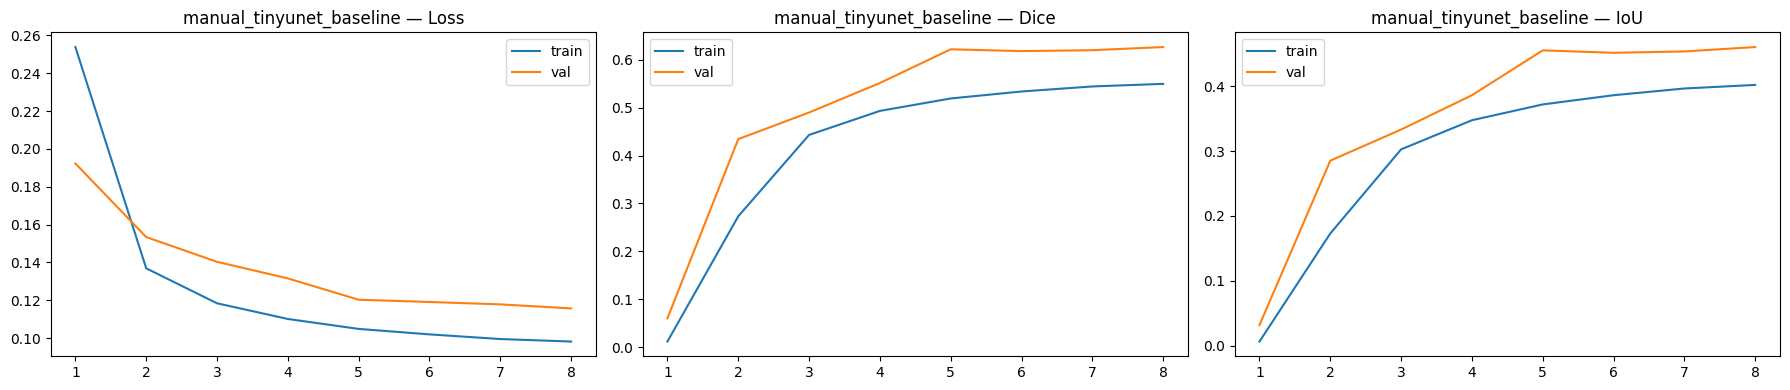

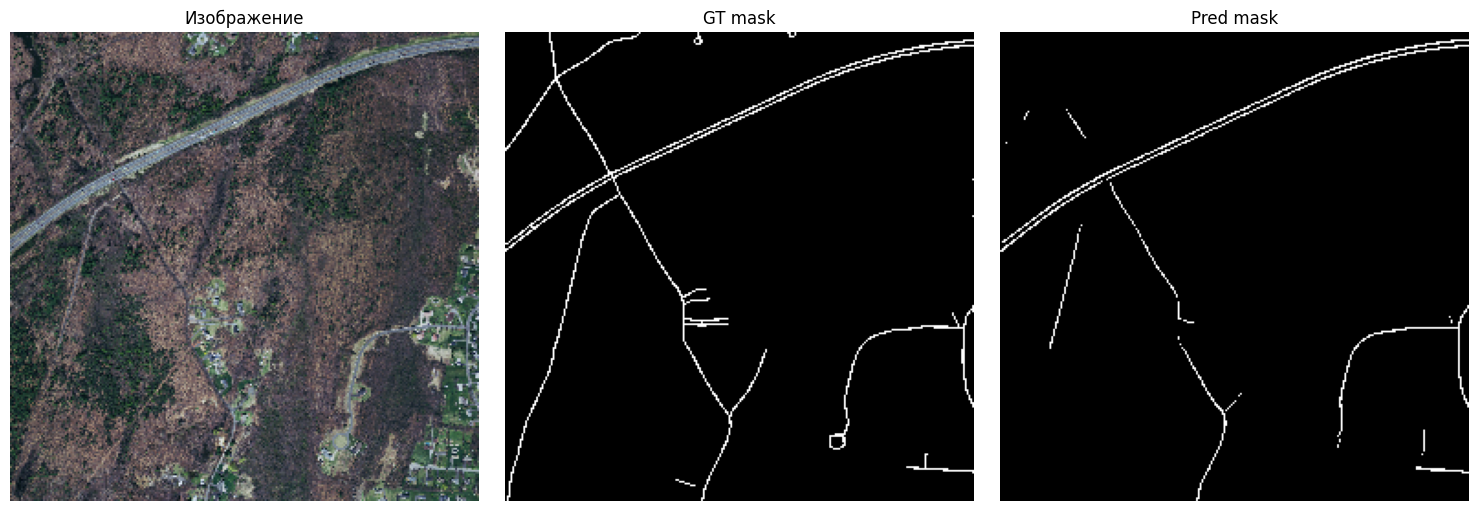

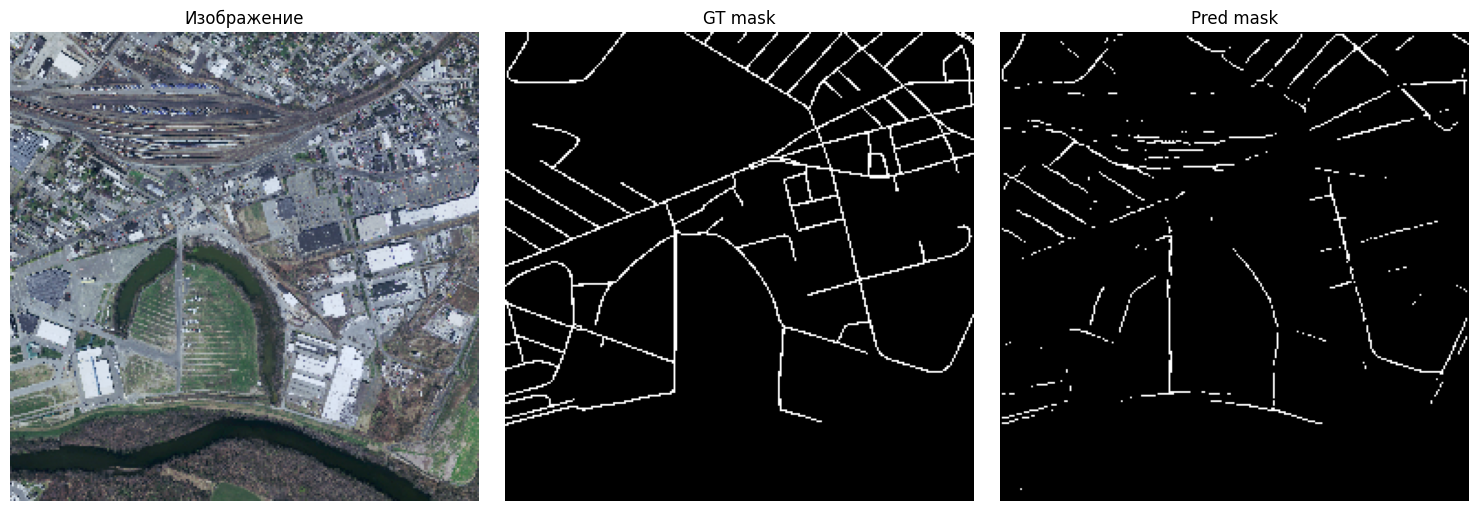

In [23]:
manual_results = []
manual_histories = {}

# 8.1 TinyUNet baseline
print("=" * 100)
print("Запуск: manual_tinyunet_baseline")

model = TinyUNet()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["manual_epochs"])

model, hist_df, best_path = fit_model(
    model=model,
    train_loader=baseline_train_loader,
    val_loader=baseline_val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=CONFIG["manual_epochs"],
    exp_name="manual_tinyunet_baseline",
    device=CONFIG["device"],
)

test_metrics = evaluate_model(model, baseline_test_loader, criterion, device=CONFIG["device"])
manual_results.append({
    "stage": "manual_baseline",
    "experiment": "manual_tinyunet_baseline",
    "arch": "tinyunet",
    "encoder": "from_scratch",
    **test_metrics,
    "checkpoint": best_path,
})
manual_histories["manual_tinyunet_baseline"] = hist_df
plot_history(hist_df, "manual_tinyunet_baseline")
visualize_predictions(model, baseline_test_loader, device=CONFIG["device"], n=2)

del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Запуск: manual_tinyunet_improved
[manual_tinyunet_improved] Epoch 01/8 | train loss=0.5748, dice=0.0950, iou=0.0544 | val loss=0.4839, dice=0.3467, iou=0.2118
[manual_tinyunet_improved] Epoch 02/8 | train loss=0.4493, dice=0.3070, iou=0.1883 | val loss=0.4316, dice=0.4122, iou=0.2608
[manual_tinyunet_improved] Epoch 03/8 | train loss=0.4085, dice=0.3714, iou=0.2366 | val loss=0.4046, dice=0.4547, iou=0.2956
[manual_tinyunet_improved] Epoch 04/8 | train loss=0.3938, dice=0.3920, iou=0.2531 | val loss=0.3774, dice=0.4920, iou=0.3277
[manual_tinyunet_improved] Epoch 05/8 | train loss=0.3877, dice=0.4028, iou=0.2617 | val loss=0.3672, dice=0.5097, iou=0.3435
[manual_tinyunet_improved] Epoch 06/8 | train loss=0.3827, dice=0.4098, iou=0.2675 | val loss=0.3557, dice=0.5298, iou=0.3616
[manual_tinyunet_improved] Epoch 07/8 | train loss=0.3765, dice=0.4178, iou=0.2740 | val loss=0.3707, dice=0.5077, iou=0.3412
[manual_tinyunet_improved] Epoch 08/8 | train loss=0.3760, dice=0.4202, iou=0.2761 | 

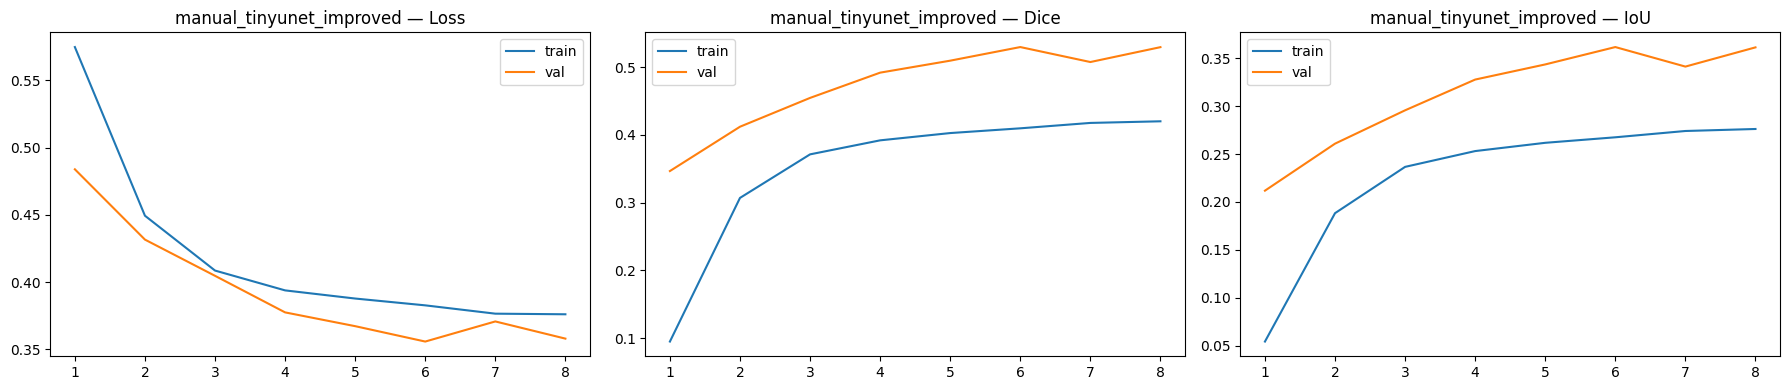

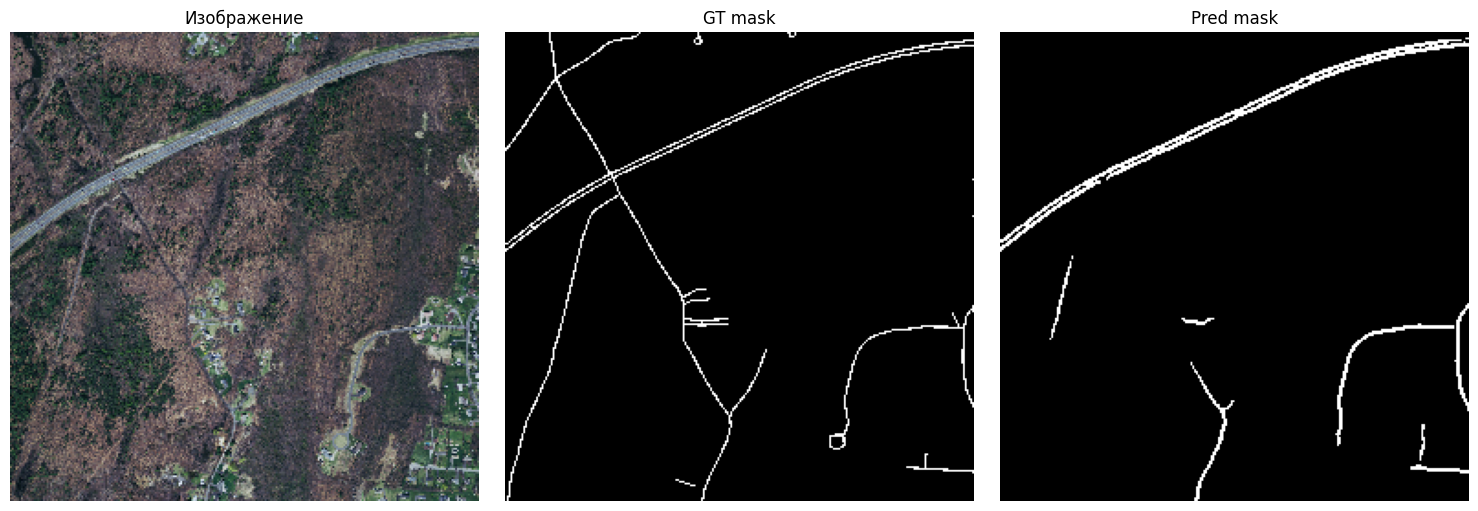

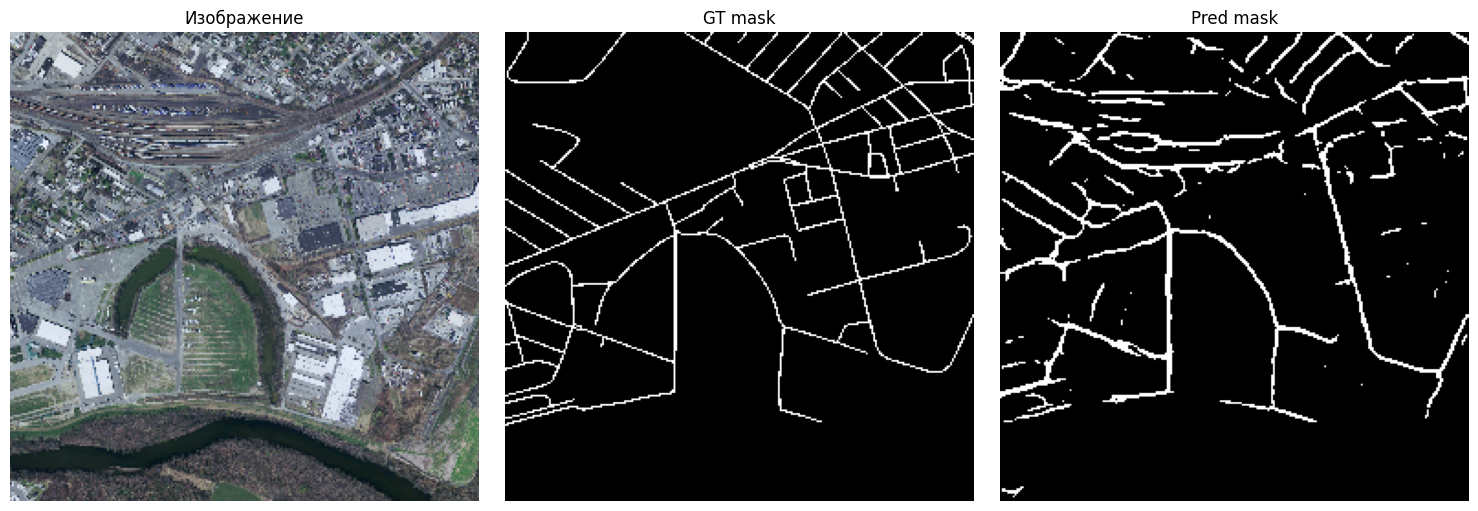

In [24]:
# 8.2 TinyUNet improved
print("=" * 100)
print("Запуск: manual_tinyunet_improved")

model = TinyUNet()
criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

model, hist_df, best_path = fit_model(
    model=model,
    train_loader=improved_train_loader,
    val_loader=improved_val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=CONFIG["manual_epochs"],
    exp_name="manual_tinyunet_improved",
    device=CONFIG["device"],
)

test_metrics = evaluate_model(model, improved_test_loader, criterion, device=CONFIG["device"])
manual_results.append({
    "stage": "manual_improved",
    "experiment": "manual_tinyunet_improved",
    "arch": "tinyunet",
    "encoder": "from_scratch",
    **test_metrics,
    "checkpoint": best_path,
})
manual_histories["manual_tinyunet_improved"] = hist_df
plot_history(hist_df, "manual_tinyunet_improved")
visualize_predictions(model, improved_test_loader, device=CONFIG["device"], n=2)

del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [1]:
manual_results_df = pd.DataFrame(manual_results).sort_values("dice", ascending=False).reset_index(drop=True)
manual_results_df

NameError: name 'pd' is not defined

## 9. Итоговое сравнение экспериментов

In [2]:
all_results_df = pd.concat(
    [baseline_results_df, improved_results_df, manual_results_df],
    ignore_index=True
).sort_values("dice", ascending=False).reset_index(drop=True)

all_results_df

NameError: name 'pd' is not defined

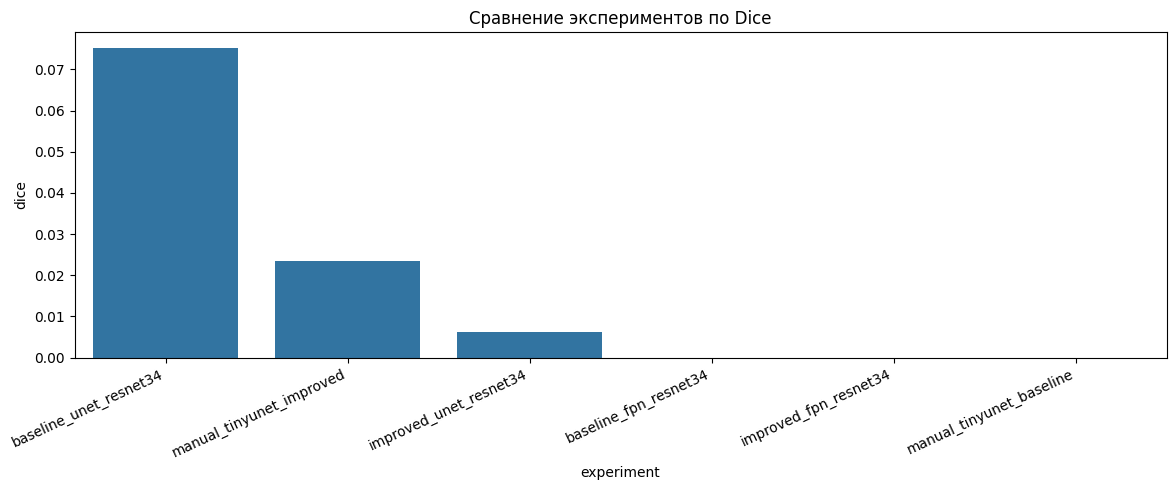

In [43]:
plt.figure(figsize=(12, 5))
sns.barplot(data=all_results_df, x="experiment", y="dice")
plt.xticks(rotation=25, ha="right")
plt.title("Сравнение экспериментов по Dice")
plt.tight_layout()
plt.show()

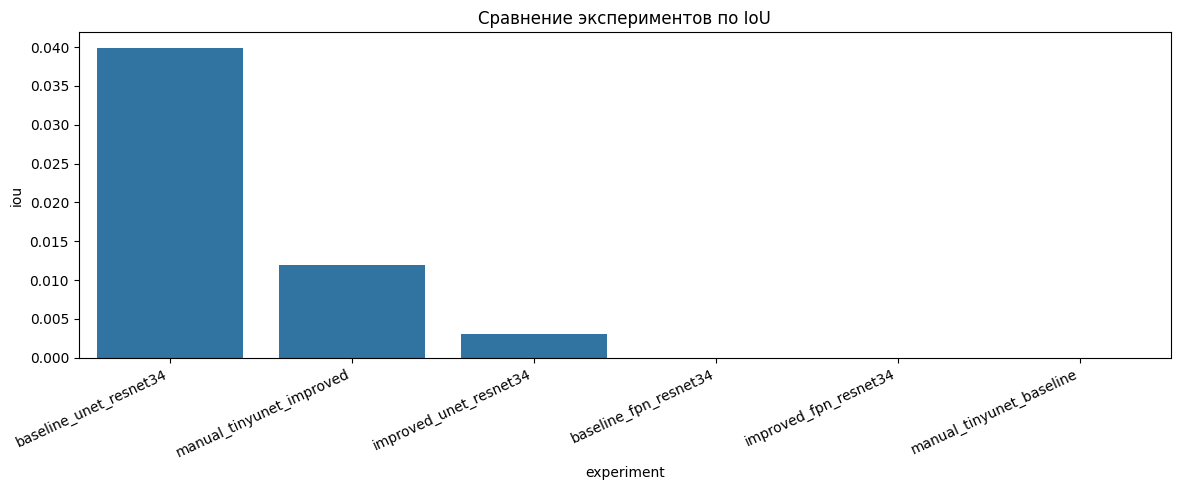

In [44]:
plt.figure(figsize=(12, 5))
sns.barplot(data=all_results_df, x="experiment", y="iou")
plt.xticks(rotation=25, ha="right")
plt.title("Сравнение экспериментов по IoU")
plt.tight_layout()
plt.show()

In [45]:
save_dir = Path(CONFIG["save_dir"])
save_dir.mkdir(parents=True, exist_ok=True)

baseline_results_df.to_csv(save_dir / "baseline_results.csv", index=False)
improved_results_df.to_csv(save_dir / "improved_results.csv", index=False)
manual_results_df.to_csv(save_dir / "manual_results.csv", index=False)
all_results_df.to_csv(save_dir / "all_results.csv", index=False)

for name, hist in baseline_histories.items():
    hist.to_csv(save_dir / f"{name}_history.csv", index=False)

for name, hist in improved_histories.items():
    hist.to_csv(save_dir / f"{name}_history.csv", index=False)

for name, hist in manual_histories.items():
    hist.to_csv(save_dir / f"{name}_history.csv", index=False)

print("Все таблицы сохранены в:", save_dir)

Все таблицы сохранены в: /content/artifacts


## 10. Автоматическая текстовая сводка для README / отчёта

Ниже ячейка сама формирует аккуратную сводку результатов, которую можно вставить в `README.md` после выполнения ноутбука.

In [46]:
def make_report_summary(all_results_df: pd.DataFrame) -> str:
    best_row = all_results_df.iloc[0]
    baseline_best = all_results_df[all_results_df["stage"] == "baseline"].sort_values("dice", ascending=False).head(1)
    improved_best = all_results_df[all_results_df["stage"] == "improved"].sort_values("dice", ascending=False).head(1)
    manual_best = all_results_df[all_results_df["stage"].str.contains("manual")].sort_values("dice", ascending=False).head(1)

    lines = []
    lines.append("Итоговая сводка экспериментов")
    lines.append("-" * 60)

    if not baseline_best.empty:
        r = baseline_best.iloc[0]
        lines.append(
            f"Лучший baseline: {r['experiment']} | Dice={r['dice']:.4f}, IoU={r['iou']:.4f}, PixelAcc={r['pixel_acc']:.4f}"
        )
    if not improved_best.empty:
        r = improved_best.iloc[0]
        lines.append(
            f"Лучший improved baseline: {r['experiment']} | Dice={r['dice']:.4f}, IoU={r['iou']:.4f}, PixelAcc={r['pixel_acc']:.4f}"
        )
    if not manual_best.empty:
        r = manual_best.iloc[0]
        lines.append(
            f"Лучшая собственная модель: {r['experiment']} | Dice={r['dice']:.4f}, IoU={r['iou']:.4f}, PixelAcc={r['pixel_acc']:.4f}"
        )

    lines.append(
        f"Лучший общий результат: {best_row['experiment']} | Dice={best_row['dice']:.4f}, IoU={best_row['iou']:.4f}, PixelAcc={best_row['pixel_acc']:.4f}"
    )
    return "\n".join(lines)

summary_text = make_report_summary(all_results_df)
print(summary_text)

with open(Path(CONFIG["save_dir"]) / "report_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

Итоговая сводка экспериментов
------------------------------------------------------------
Лучший baseline: baseline_unet_resnet34 | Dice=0.0752, IoU=0.0399, PixelAcc=0.7622
Лучший improved baseline: improved_unet_resnet34 | Dice=0.0062, IoU=0.0031, PixelAcc=0.9530
Лучшая собственная модель: manual_tinyunet_improved | Dice=0.0234, IoU=0.0119, PixelAcc=0.9522
Лучший общий результат: baseline_unet_resnet34 | Dice=0.0752, IoU=0.0399, PixelAcc=0.7622


## 11. Выводы

После выполнения всех ячеек у Вас будут:

- обученные веса моделей (`*.pth`);
- таблицы с метриками (`baseline_results.csv`, `improved_results.csv`, `manual_results.csv`, `all_results.csv`);
- истории обучения;
- графики сходимости;
- визуализации предсказаний;
- готовая текстовая сводка для вставки в README и отчёт.

Что обычно нужно написать в итоговом выводе:
1. какая baseline-модель оказалась сильнее;
2. какие гипотезы действительно улучшили Dice / IoU;
3. насколько улучшенный бейзлайн превзошёл baseline;
4. насколько собственная TinyUNet уступила или приблизилась к библиотечным моделям;
5. какие ограничения есть у решения (размер входа, время обучения, тонкие дороги, ложные срабатывания на светлых объектах).